<a href="https://colab.research.google.com/github/ParushiSrivastava/PARUSHI.23FE10CSE00380/blob/main/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759)

# data (as pandas dataframes)
X = glioma_grading_clinical_and_mutation_features.data.features
y = glioma_grading_clinical_and_mutation_features.data.targets

# metadata
print(glioma_grading_clinical_and_mutation_features.metadata)

# variable information
print(glioma_grading_clinical_and_mutation_features.variables)


{'uci_id': 759, 'name': 'Glioma Grading Clinical and Mutation Features', 'repository_url': 'https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/759/data.csv', 'abstract': 'Gliomas are the most common primary tumors of the brain. They can be graded as LGG (Lower-Grade Glioma) or GBM (Glioblastoma Multiforme) depending on the histological/imaging criteria. Clinical and molecular/mutation factors are also very crucial for the grading process. Molecular tests are expensive to help accurately diagnose glioma patients.    In this dataset, the most frequently mutated 20 genes and 3 clinical features are considered from TCGA-LGG and TCGA-GBM brain glioma projects.  The prediction task is to determine whether a patient is LGG or GBM with a given clinical and molecular/mutation features. The main objective is to find the optimal subset of mutation genes and clinical features for the glioma grading 

In [ ]:
# Encode categorical features
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Encode target
y_encoded = le.fit_transform(y.iloc[:,0])

# Feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

/tmp/ipykernel_2739/4084468236.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y_encoded,

    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Hidden Layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [ ]:
history = model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=16,

    validation_data=(X_test, y_test)
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6244 - loss: 0.6565 - val_accuracy: 0.6071 - val_loss: 0.6355
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7258 - loss: 0.5719 - val_accuracy: 0.6964 - val_loss: 0.5669
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7854 - loss: 0.4974 - val_accuracy: 0.7798 - val_loss: 0.4990
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8316 - loss: 0.4309 - val_accuracy: 0.8333 - val_loss: 0.4443
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8554 - loss: 0.3856 - val_accuracy: 0.8393 - val_loss: 0.4082
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8718 - loss: 0.3564 - val_accuracy: 0.8571 - val_loss: 0.3866
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8748 - loss: 0.3375 - val_accuracy: 0.8512 - val_loss: 0.3768
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8718 - loss: 0.3232 - val_accuracy: 0.8571 - val_loss

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Convert probabilities → 0 or 1
y_pred = (y_pred > 0.5)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[72 17]
 [14 65]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        89
           1       0.79      0.82      0.81        79

    accuracy                           0.82       168
   macro avg       0.81      0.82      0.82       168
weighted avg       0.82      0.82      0.82       168



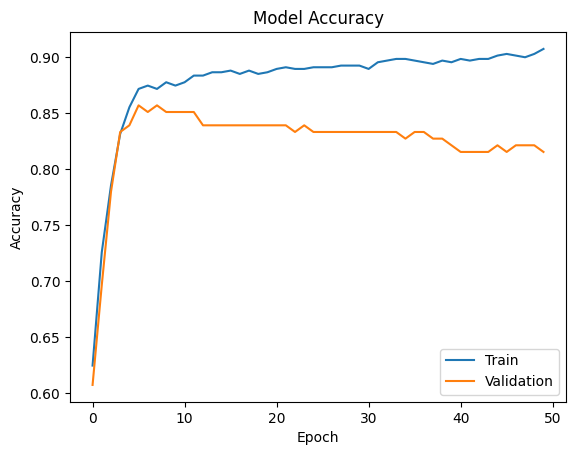

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()